In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU found")

CUDA available: True
GPU name: Tesla T4


In [2]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.9 MB/s eta 0:00:00


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/final_dataset_all.zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully.")
print(os.listdir("/content"))

Unzipped successfully.
['.config', 'drive', 'final_dataset_all', '__MACOSX', 'sample_data']


In [8]:
import os

base_path = "/content/final_dataset_all"

for root, dirs, files_ in os.walk(base_path):
    print(root, "->", len(files_))

/content/final_dataset_all -> 1
/content/final_dataset_all/valid -> 0
/content/final_dataset_all/valid/images -> 117
/content/final_dataset_all/valid/labels -> 117
/content/final_dataset_all/test -> 0
/content/final_dataset_all/test/images -> 60
/content/final_dataset_all/test/labels -> 60
/content/final_dataset_all/train -> 0
/content/final_dataset_all/train/images -> 412
/content/final_dataset_all/train/labels -> 412


In [9]:
yaml_path = "/content/final_dataset_all/data.yaml"

with open(yaml_path, "r") as f:
    print(f.read())

train: train/images
val: valid/images
test: test/images

nc: 3
names: ['person', 'helmet', 'vest']



In [10]:
yaml_content = """train: /content/final_dataset_all/train/images
val: /content/final_dataset_all/valid/images
test: /content/final_dataset_all/test/images

nc: 3
names: ['person', 'helmet', 'vest']
"""

with open("/content/final_dataset_all/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml updated.")

data.yaml updated.


In [11]:
from pathlib import Path

for split in ["train", "valid", "test"]:
    image_count = len(list(Path(f"/content/final_dataset_all/{split}/images").glob("*.*")))
    label_count = len(list(Path(f"/content/final_dataset_all/{split}/labels").glob("*.txt")))
    print(f"{split}: images={image_count}, labels={label_count}")

train: images=412, labels=412
valid: images=117, labels=117
test: images=60, labels=60


In [12]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="/content/final_dataset_all/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    project="/content/runs",
    name="ppe_safety_model",
    pretrained=True,
    patience=10,
    save=True
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/final_dataset_all/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=

In [13]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2622.7±997.2 MB/s, size: 207.9 KB)
val: Scanning /content/final_dataset_all/valid/labels.cache... 117 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 117/117 28.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.1it/s 3.9s
                   all        117       1007      0.853      0.749      0.812      0.521
                person        117        414      0.897      0.766      0.826      0.545
                helmet        109        341      0.892      0.757      0.842      0.524
                  vest        102        252      0.769      0.725      0.769      0.495
Speed: 4.0ms preprocess, 7.7ms inference, 0.0ms loss, 4.0ms postprocess per image
Results saved to /content/runs/detect/val
ultra

In [14]:
best_model_path = "/content/runs/ppe_safety_model/weights/best.pt"
print("Best model path:", best_model_path)
print("Exists:", os.path.exists(best_model_path))

Best model path: /content/runs/ppe_safety_model/weights/best.pt
Exists: True


In [15]:
import os

for root, dirs, files_ in os.walk("/content/runs"):
    for f in files_:
        if f == "best.pt":
            print("Found:", os.path.join(root, f))

Found: /content/runs/ppe_safety_model/weights/best.pt


In [16]:
from ultralytics import YOLO

trained_model = YOLO("/content/runs/ppe_safety_model/weights/best.pt")

In [27]:
pred_results = trained_model.predict(
    source="/content/final_dataset_all/test/images",
    save=True,
    conf=0.50
)


image 1/60 /content/final_dataset_all/test/images/ds1_00103_jpg.rf.sSouBKyJwsGbMQhQmxeD.jpg: 640x640 2 persons, 1 helmet, 2 vests, 8.3ms
image 2/60 /content/final_dataset_all/test/images/ds1_4843_RolePlay_ConstructionWorker_BoyGirl_jpg.rf.HN3kcSNSTzjBcs7pMqzi.jpg: 640x640 2 persons, 2 helmets, 2 vests, 7.2ms
image 3/60 /content/final_dataset_all/test/images/ds1_Aitin0150_jpg.rf.BD8B5iJm4HgNVQDixfJT.jpg: 384x640 1 person, 1 helmet, 1 vest, 6.7ms
image 4/60 /content/final_dataset_all/test/images/ds1_Aitin2428_jpg.rf.60StvxlWmZS5zAOnS3Pb.jpg: 384x640 2 persons, 2 helmets, 1 vest, 5.8ms
image 5/60 /content/final_dataset_all/test/images/ds1_KakaoTalk_20221018_001219713_15_jpg.rf.rWQwISJghYuoLk9sji0x.jpg: 640x640 1 person, 1 helmet, 1 vest, 7.8ms
image 6/60 /content/final_dataset_all/test/images/ds1_KakaoTalk_20221018_001312059_02_jpg.rf.4zY8uWxlZzHIOjBoBncX.jpg: 640x640 1 person, 1 helmet, 1 vest, 7.2ms
image 7/60 /content/final_dataset_all/test/images/ds1_KakaoTalk_20221018_001425789_07_j

In [28]:
class_names = ['person', 'helmet', 'vest']

for r in pred_results[:3]:
    print("Image:", r.path.split("/")[-1])

    for i in range(len(r.boxes)):
        cls_id = int(r.boxes.cls[i].item())
        conf = float(r.boxes.conf[i].item())

        print(class_names[cls_id], round(conf, 3), r.boxes.xyxy[i].tolist())

    print("-" * 60)

Image: ds1_00103_jpg.rf.sSouBKyJwsGbMQhQmxeD.jpg
person 0.905 [240.70840454101562, 1.729726791381836, 462.2467041015625, 499.35150146484375]
person 0.859 [17.977046966552734, 3.8225173950195312, 229.43653869628906, 498.687744140625]
vest 0.813 [255.29327392578125, 127.05378723144531, 456.333740234375, 444.5534362792969]
helmet 0.757 [90.64850616455078, 3.3141791820526123, 189.73867797851562, 79.23896026611328]
vest 0.531 [37.750125885009766, 140.6815948486328, 153.06423950195312, 421.9586486816406]
------------------------------------------------------------
Image: ds1_4843_RolePlay_ConstructionWorker_BoyGirl_jpg.rf.HN3kcSNSTzjBcs7pMqzi.jpg
vest 0.924 [366.453369140625, 215.9195556640625, 544.6504516601562, 490.3428955078125]
person 0.859 [71.31610107421875, 67.96728515625, 294.334228515625, 597.410888671875]
person 0.811 [314.9910888671875, 55.997314453125, 618.89990234375, 596.767578125]
helmet 0.81 [393.85931396484375, 55.05256652832031, 525.7314453125, 162.43206787109375]
helmet 0.

Prediction folder exists: True
['ds1_00103_jpg.rf.sSouBKyJwsGbMQhQmxeD.jpg', 'ds1_4843_RolePlay_ConstructionWorker_BoyGirl_jpg.rf.HN3kcSNSTzjBcs7pMqzi.jpg', 'ds1_Aitin0150_jpg.rf.BD8B5iJm4HgNVQDixfJT.jpg', 'ds1_Aitin2428_jpg.rf.60StvxlWmZS5zAOnS3Pb.jpg', 'ds1_KakaoTalk_20221018_001219713_15_jpg.rf.rWQwISJghYuoLk9sji0x.jpg', 'ds1_KakaoTalk_20221018_001312059_02_jpg.rf.4zY8uWxlZzHIOjBoBncX.jpg', 'ds1_KakaoTalk_20221018_001425789_07_jpg.rf.KBIcTBx3YON51BFRrJWG.jpg', 'ds1_KakaoTalk_20221018_001425789_23_jpg.rf.mbNsOzcxMAW2EOjG7WVK.jpg', 'ds1_KakaoTalk_20221018_001726988_01_jpg.rf.uWM0HRqQIprMYBGP7b0U.jpg', 'ds1_TNPDu_78_jpg.rf.5UYFR5ZxjxOb29Uyufbw.jpg']


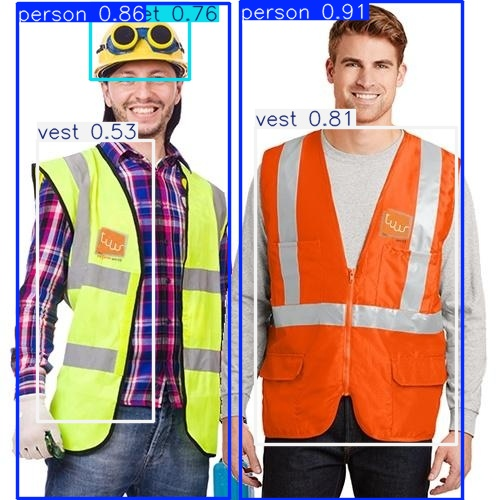

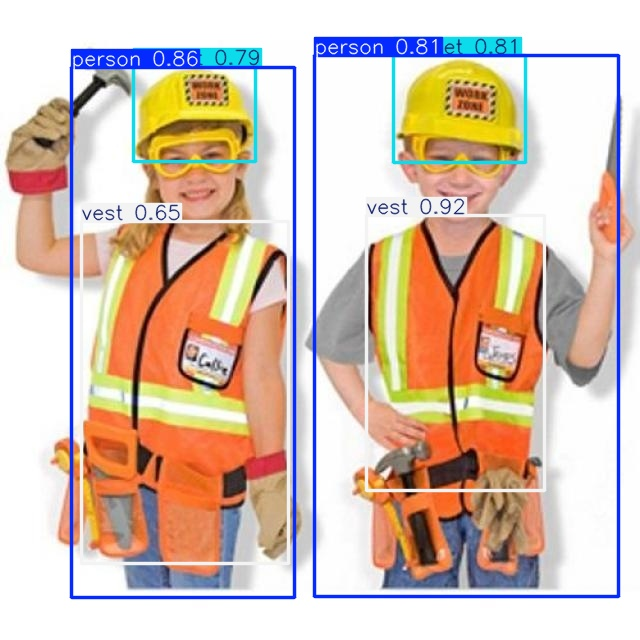

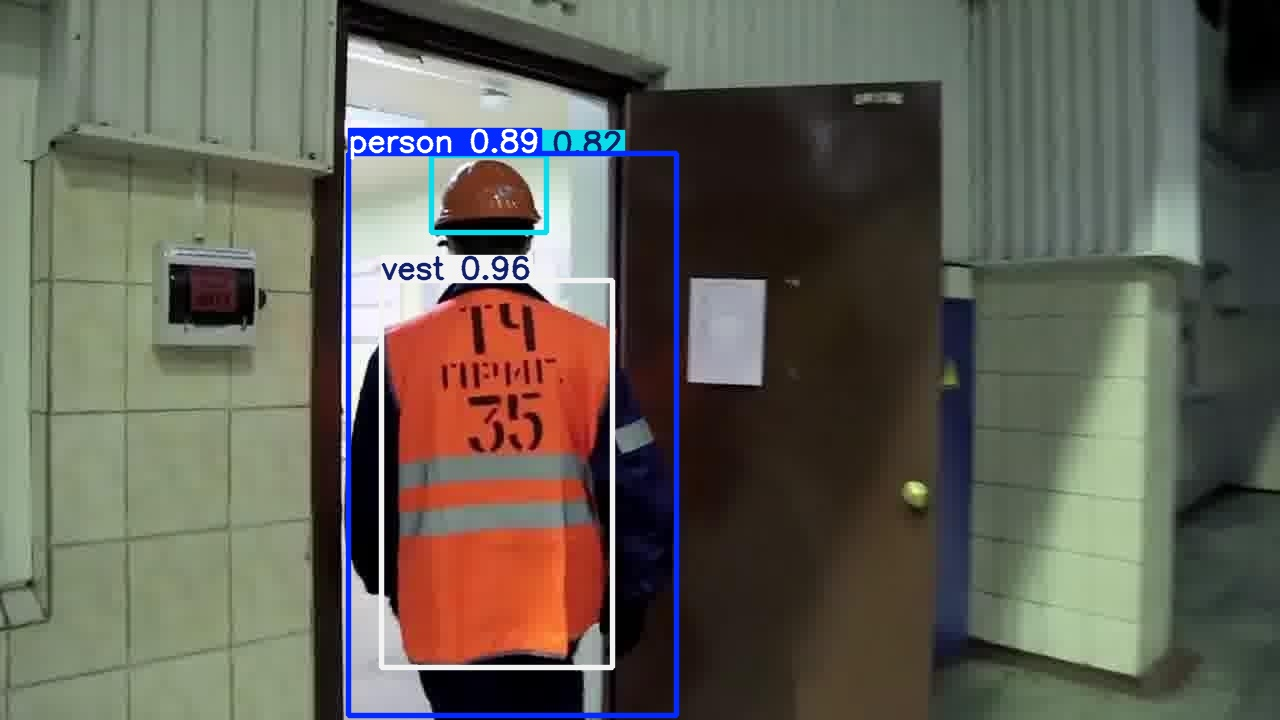

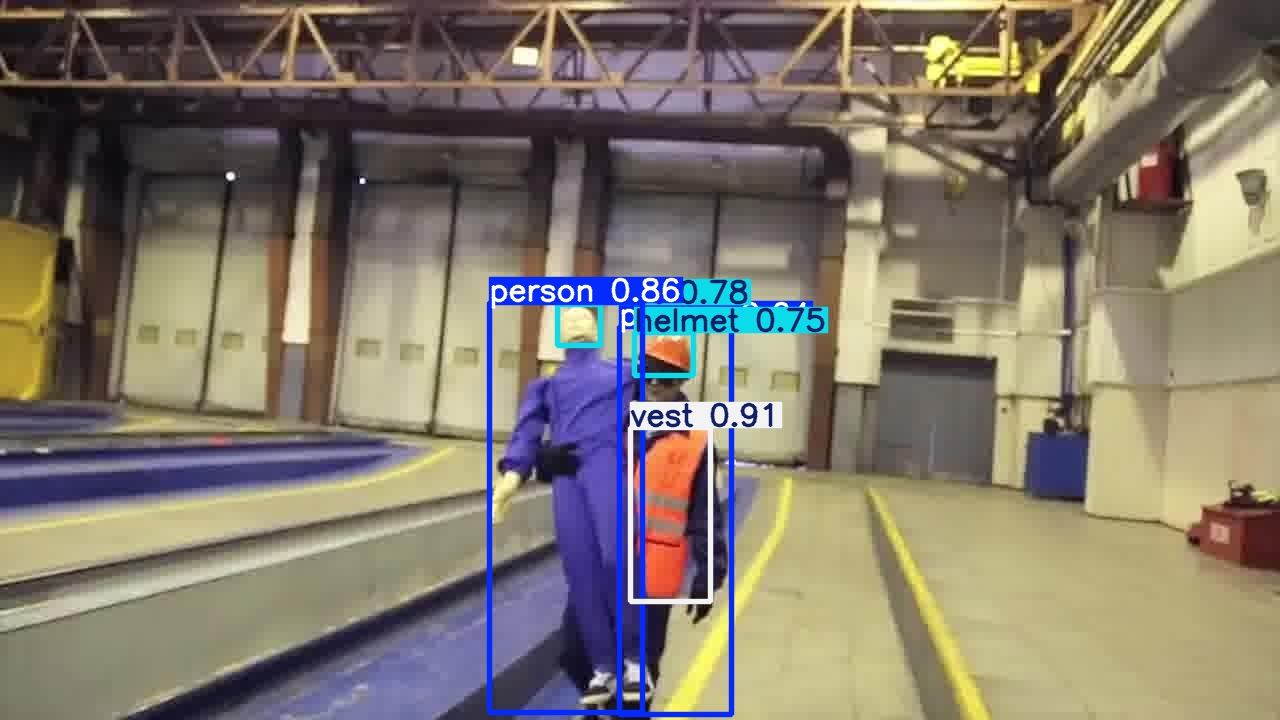

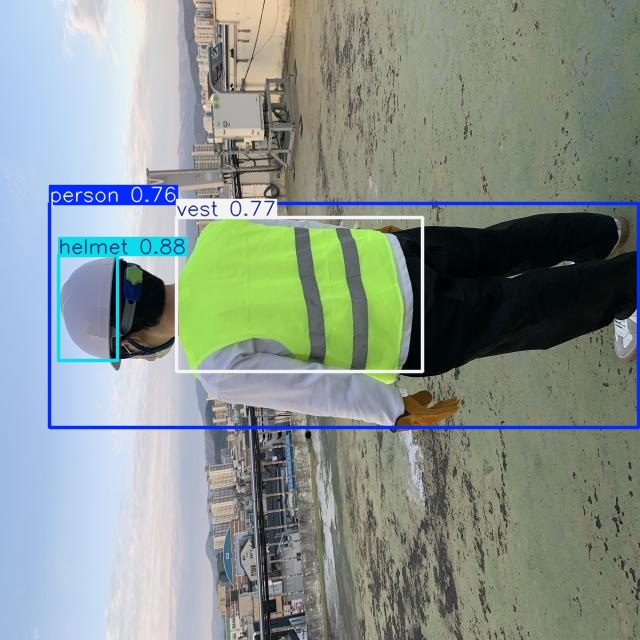

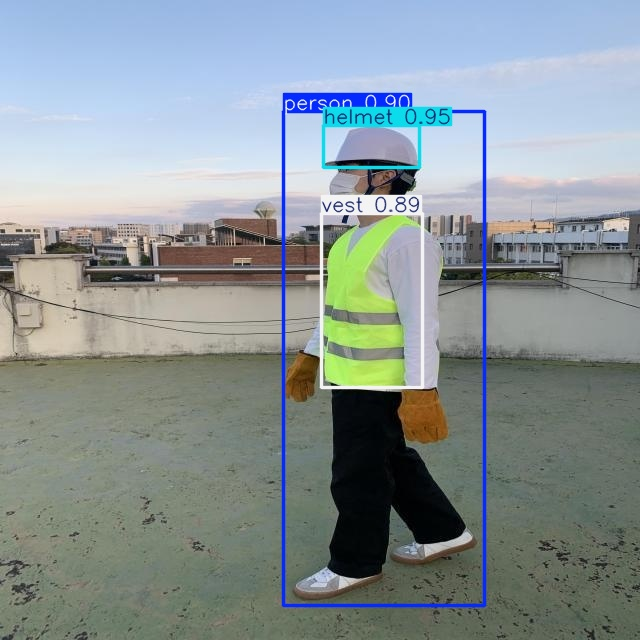

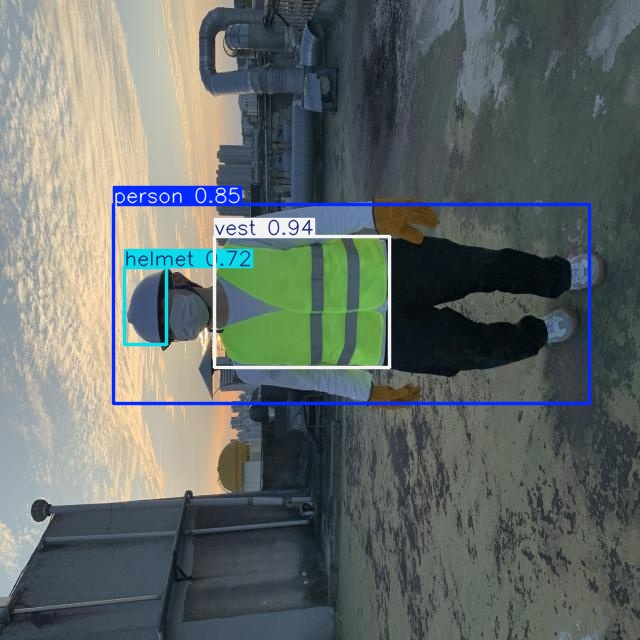

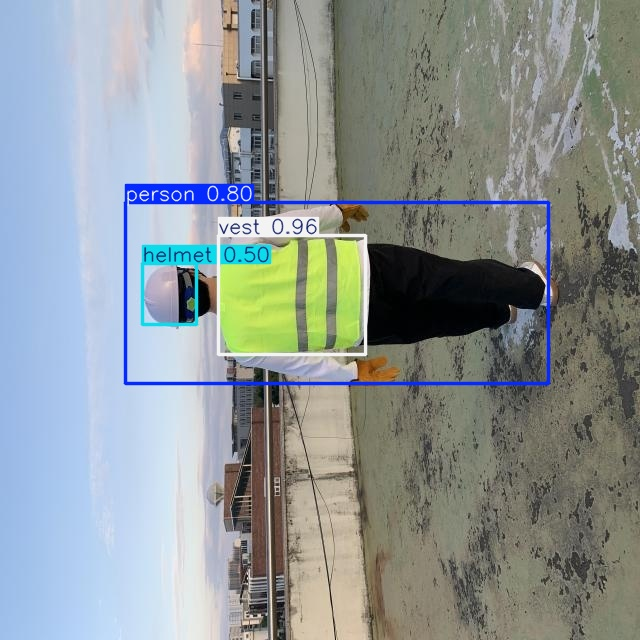

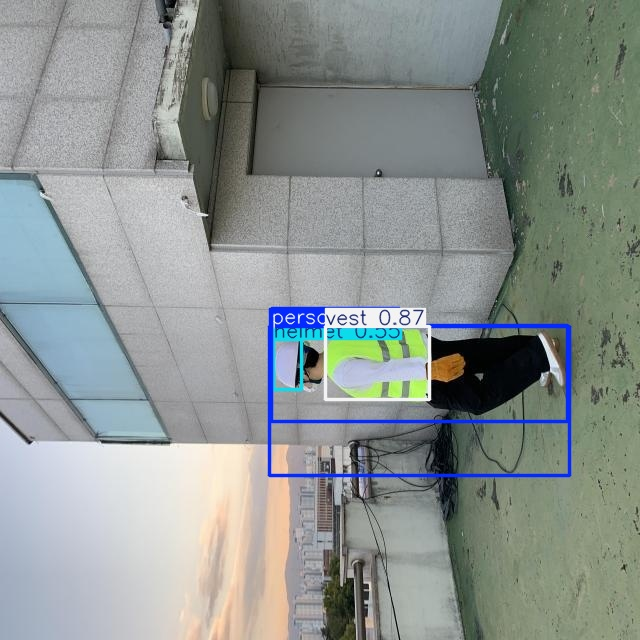

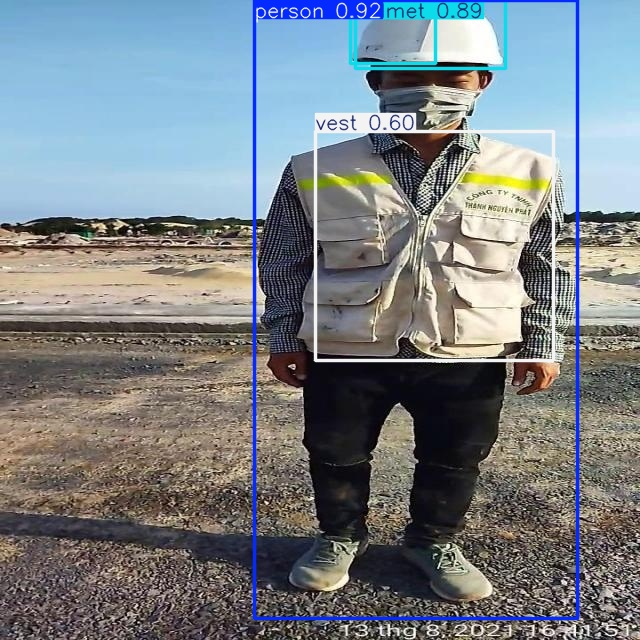

In [29]:
import os
from IPython.display import Image, display

pred_folder = "/content/runs/detect/predict"
print("Prediction folder exists:", os.path.exists(pred_folder))

files_list = sorted(os.listdir(pred_folder))[:10]
print(files_list)

for file_name in files_list:
    file_path = os.path.join(pred_folder, file_name)
    display(Image(filename=file_path, width=700))

In [30]:
import os

for root, dirs, files_ in os.walk("/content/runs"):
    if "predict" in root:
        print(root)

/content/runs/detect/predict


In [31]:
from collections import Counter
import os

class_names = ['person', 'helmet', 'vest']

def evaluate_safety(result):
    boxes = result.boxes
    if boxes is None or len(boxes) == 0:
        return {
            "persons": 0,
            "helmets": 0,
            "vests": 0,
            "status": "NO WORKER DETECTED"
        }

    detected_classes = [int(c.item()) for c in boxes.cls]
    labels = [class_names[i] for i in detected_classes]
    counts = Counter(labels)

    persons = counts.get("person", 0)
    helmets = counts.get("helmet", 0)
    vests = counts.get("vest", 0)

    if persons == 0:
        status = "NO WORKER DETECTED"
    elif helmets < persons or vests < persons:
        status = "UNSAFE"
    else:
        status = "SAFE"

    return {
        "persons": persons,
        "helmets": helmets,
        "vests": vests,
        "status": status
    }

for i, result in enumerate(pred_results[:10]):
    info = evaluate_safety(result)
    image_name = os.path.basename(result.path)
    print(f"Image: {image_name}")
    print(info)
    print("-" * 50)

Image: ds1_00103_jpg.rf.sSouBKyJwsGbMQhQmxeD.jpg
{'persons': 2, 'helmets': 1, 'vests': 2, 'status': 'UNSAFE'}
--------------------------------------------------
Image: ds1_4843_RolePlay_ConstructionWorker_BoyGirl_jpg.rf.HN3kcSNSTzjBcs7pMqzi.jpg
{'persons': 2, 'helmets': 2, 'vests': 2, 'status': 'SAFE'}
--------------------------------------------------
Image: ds1_Aitin0150_jpg.rf.BD8B5iJm4HgNVQDixfJT.jpg
{'persons': 1, 'helmets': 1, 'vests': 1, 'status': 'SAFE'}
--------------------------------------------------
Image: ds1_Aitin2428_jpg.rf.60StvxlWmZS5zAOnS3Pb.jpg
{'persons': 2, 'helmets': 2, 'vests': 1, 'status': 'UNSAFE'}
--------------------------------------------------
Image: ds1_KakaoTalk_20221018_001219713_15_jpg.rf.rWQwISJghYuoLk9sji0x.jpg
{'persons': 1, 'helmets': 1, 'vests': 1, 'status': 'SAFE'}
--------------------------------------------------
Image: ds1_KakaoTalk_20221018_001312059_02_jpg.rf.4zY8uWxlZzHIOjBoBncX.jpg
{'persons': 1, 'helmets': 1, 'vests': 1, 'status': 'SAFE'

Image: ds1_00103_jpg.rf.sSouBKyJwsGbMQhQmxeD.jpg
Persons: 2
Helmets: 1
Vests: 2
STATUS: UNSAFE


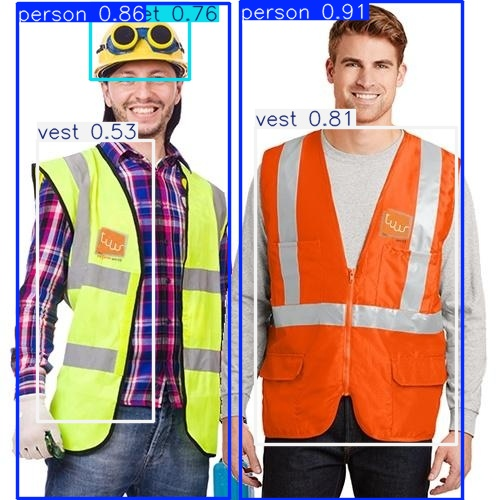

Image: ds1_4843_RolePlay_ConstructionWorker_BoyGirl_jpg.rf.HN3kcSNSTzjBcs7pMqzi.jpg
Persons: 2
Helmets: 2
Vests: 2
STATUS: SAFE


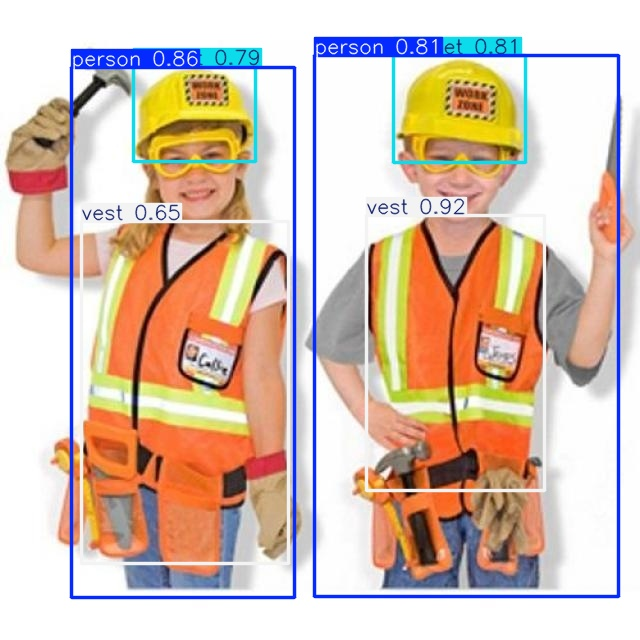

Image: ds1_Aitin0150_jpg.rf.BD8B5iJm4HgNVQDixfJT.jpg
Persons: 1
Helmets: 1
Vests: 1
STATUS: SAFE


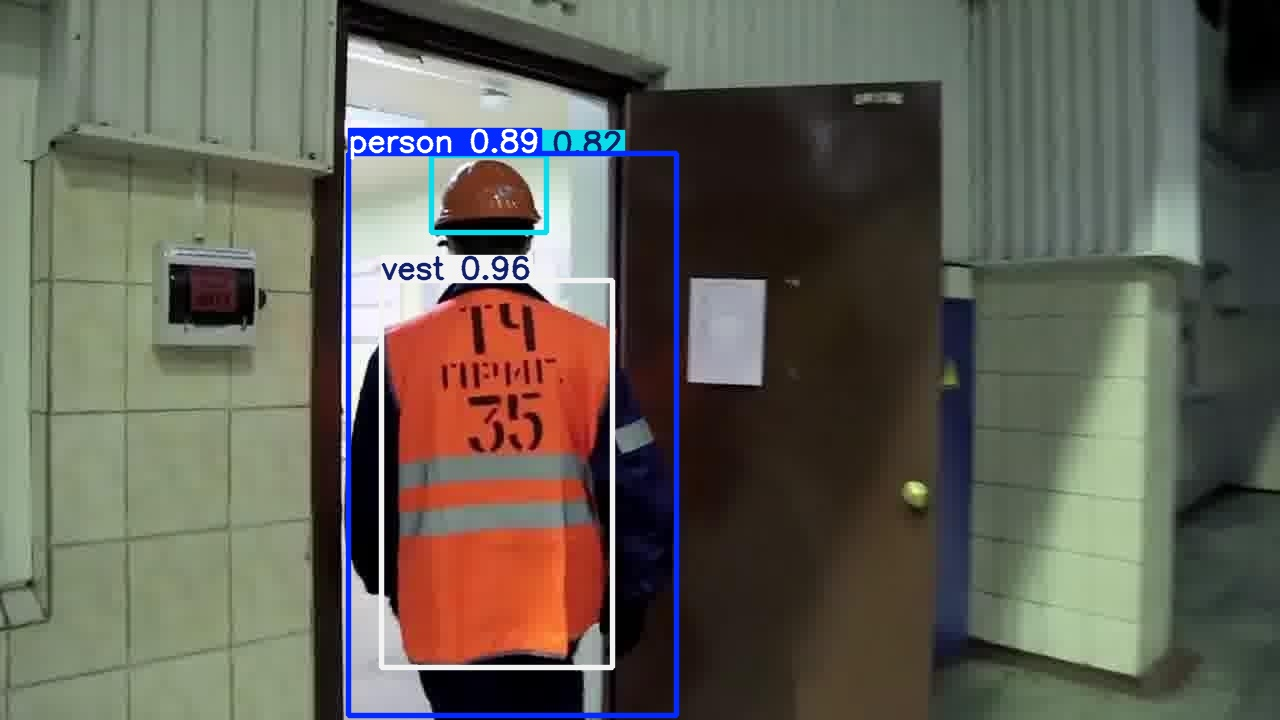

Image: ds1_Aitin2428_jpg.rf.60StvxlWmZS5zAOnS3Pb.jpg
Persons: 2
Helmets: 2
Vests: 1
STATUS: UNSAFE


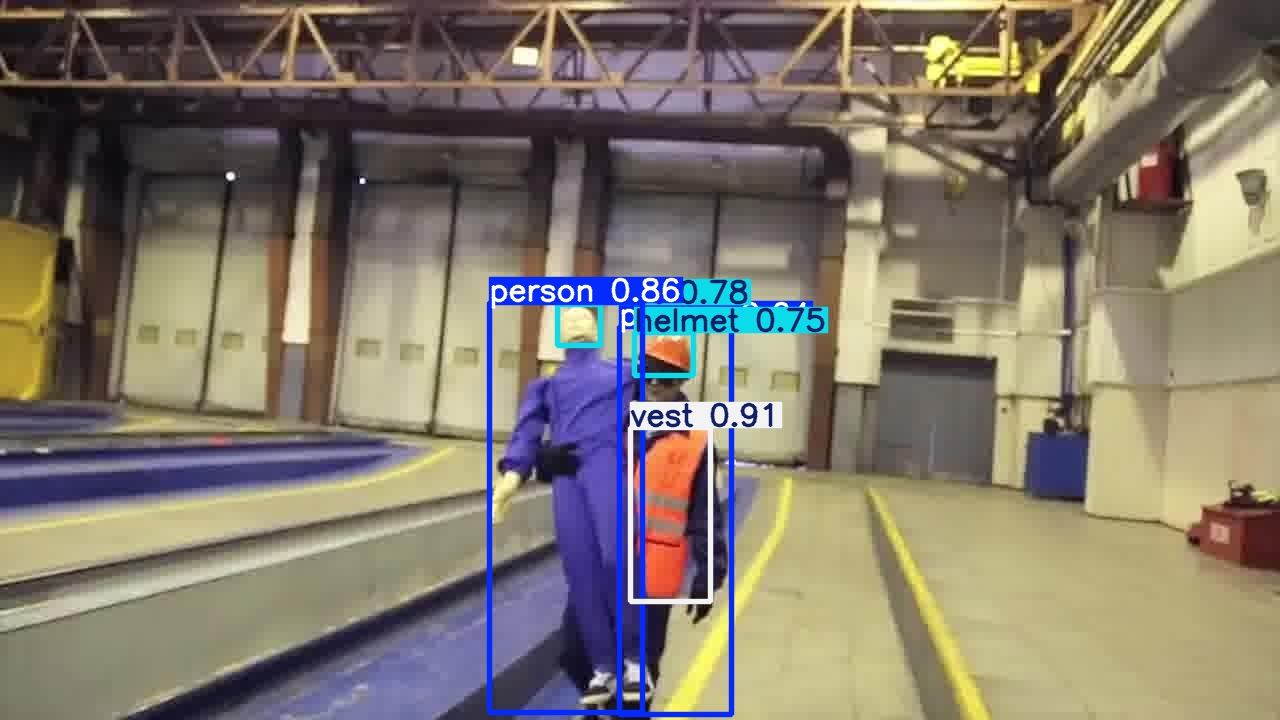

Image: ds1_KakaoTalk_20221018_001219713_15_jpg.rf.rWQwISJghYuoLk9sji0x.jpg
Persons: 1
Helmets: 1
Vests: 1
STATUS: SAFE


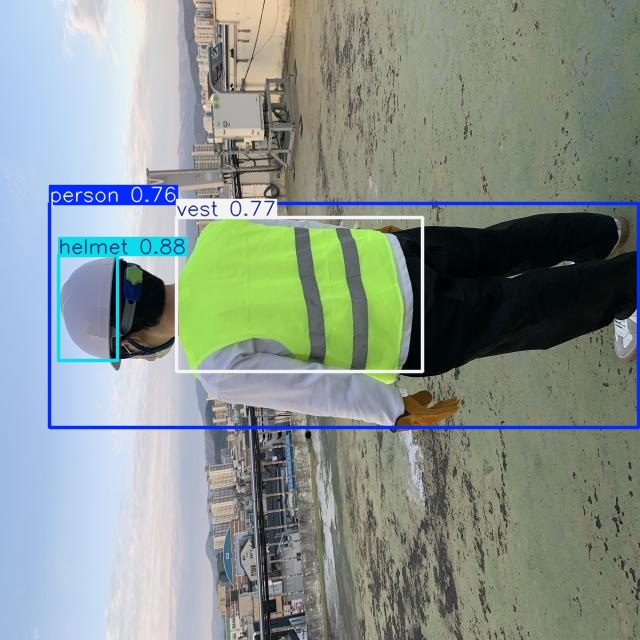

In [32]:
from IPython.display import display, Image as IPImage

for i, result in enumerate(pred_results[:5]):
    info = evaluate_safety(result)
    image_name = os.path.basename(result.path)
    predicted_image_path = f"/content/runs/detect/predict/{image_name}"

    print(f"Image: {image_name}")
    print(f"Persons: {info['persons']}")
    print(f"Helmets: {info['helmets']}")
    print(f"Vests: {info['vests']}")
    print(f"STATUS: {info['status']}")
    display(IPImage(filename=predicted_image_path, width=700))
    print("=" * 70)

In [34]:
import pandas as pd
import os

report_rows = []

for result in pred_results:
    info = evaluate_safety(result)
    image_name = os.path.basename(result.path)

    report_rows.append({
        "image": image_name,
        "persons": info["persons"],
        "helmets": info["helmets"],
        "vests": info["vests"],
        "status": info["status"]
    })

df = pd.DataFrame(report_rows)
df.to_csv("/content/safety_report.csv", index=False)

print(df.head())
print("Saved to /content/safety_report.csv")

                                               image  persons  helmets  vests  \
0          ds1_00103_jpg.rf.sSouBKyJwsGbMQhQmxeD.jpg        2        1      2   
1  ds1_4843_RolePlay_ConstructionWorker_BoyGirl_j...        2        2      2   
2      ds1_Aitin0150_jpg.rf.BD8B5iJm4HgNVQDixfJT.jpg        1        1      1   
3      ds1_Aitin2428_jpg.rf.60StvxlWmZS5zAOnS3Pb.jpg        2        2      1   
4  ds1_KakaoTalk_20221018_001219713_15_jpg.rf.rWQ...        1        1      1   

   status  
0  UNSAFE  
1    SAFE  
2    SAFE  
3  UNSAFE  
4    SAFE  
Saved to /content/safety_report.csv


In [35]:
from google.colab import files
files.download("/content/safety_report.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

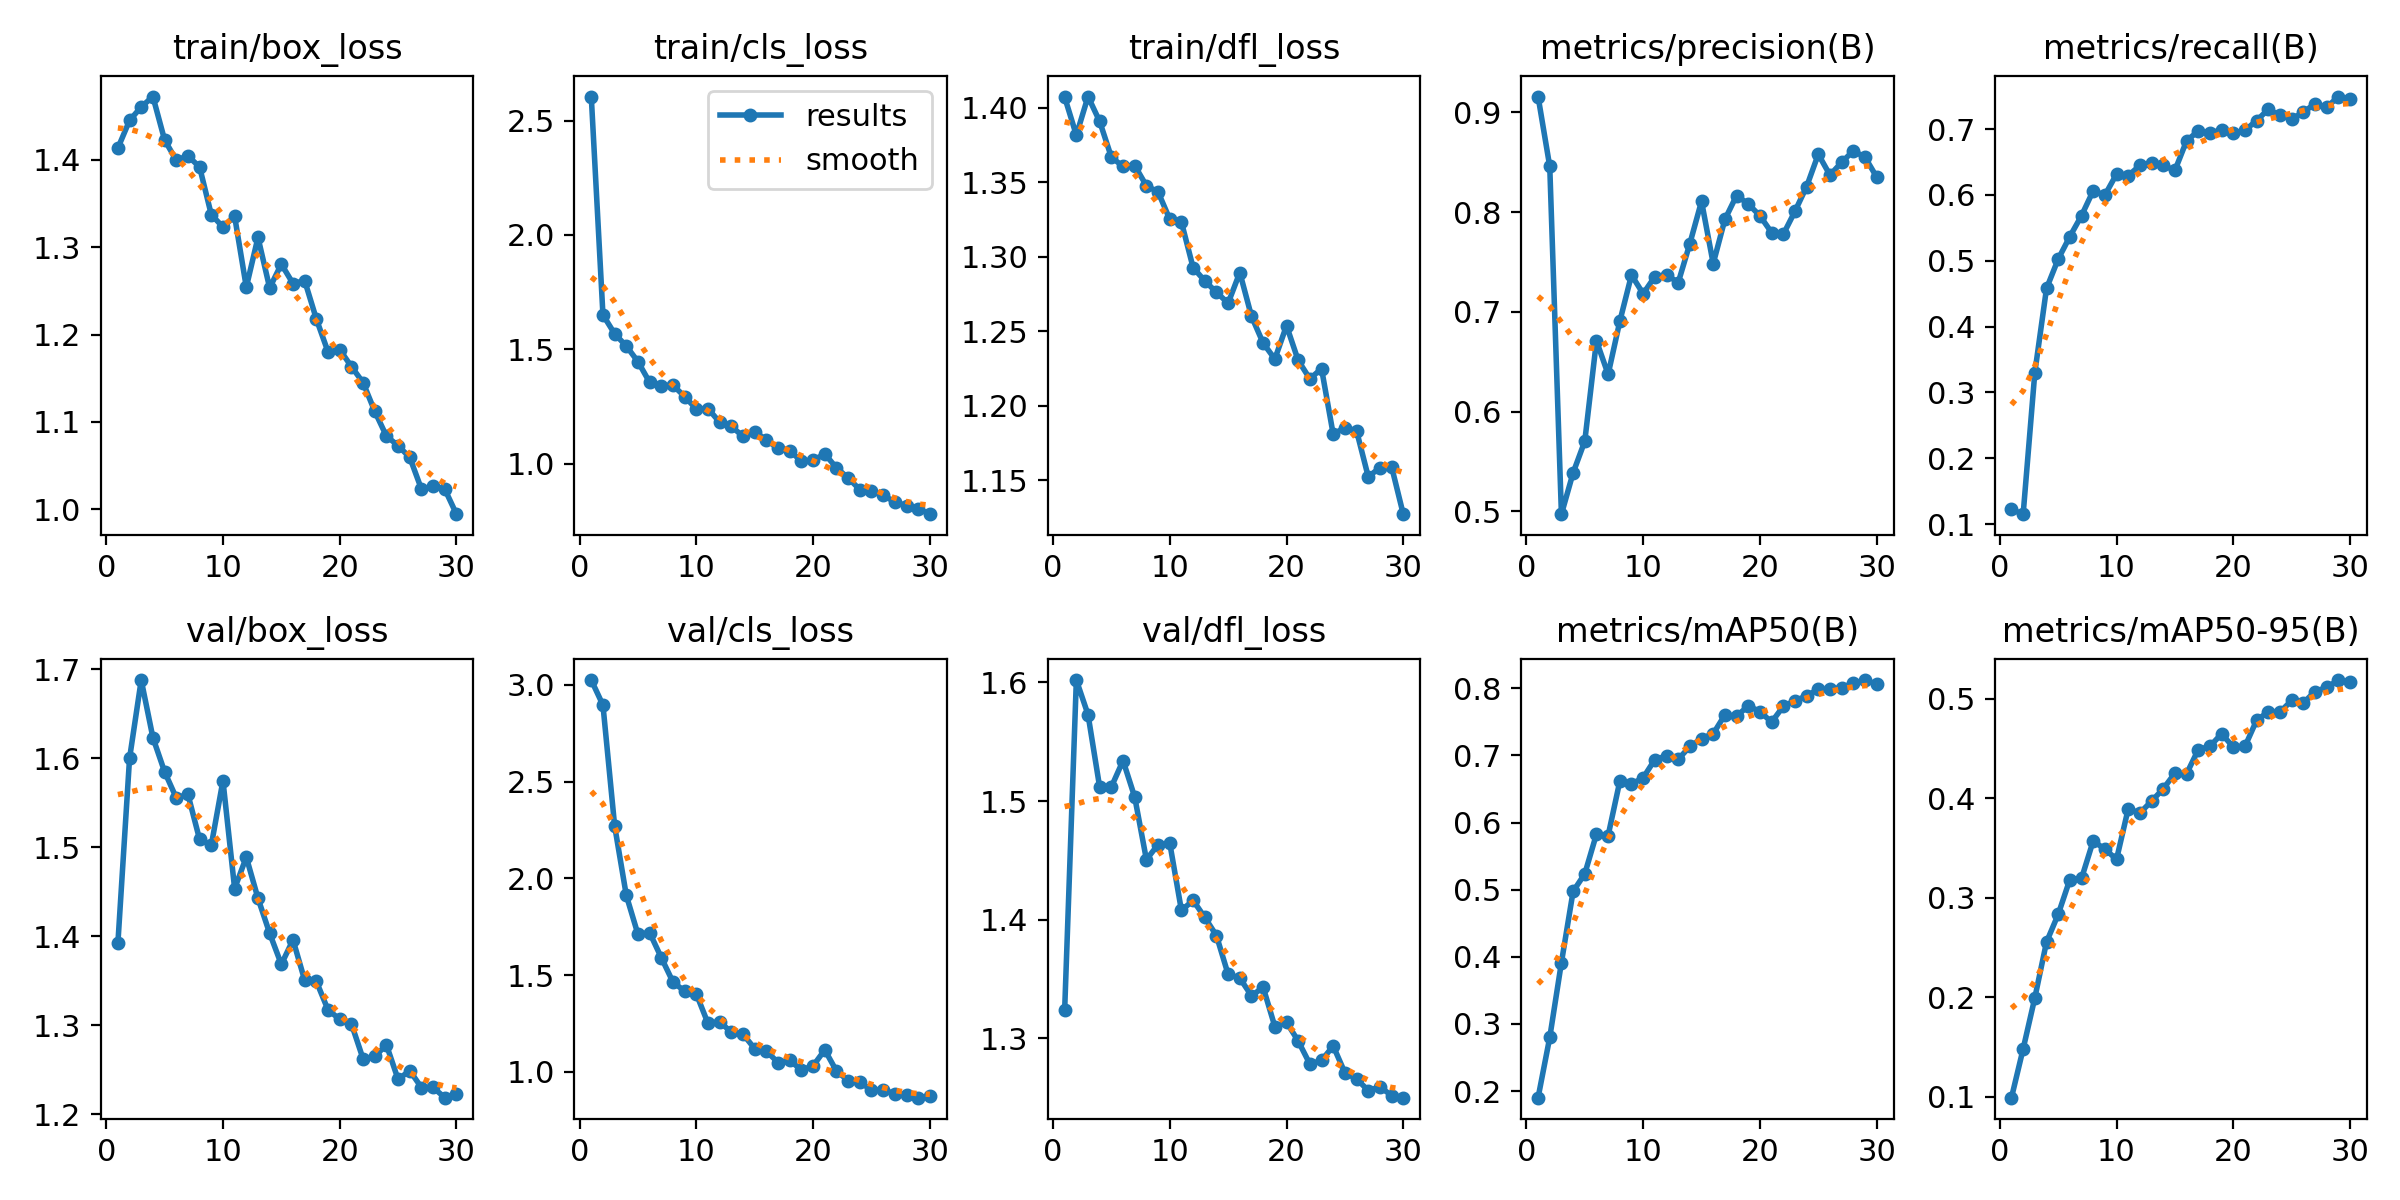

In [36]:
from IPython.display import Image, display
display(Image(filename="/content/runs/ppe_safety_model/results.png", width=900))


In [37]:
import os

for root, dirs, files_ in os.walk("/content/runs"):
    for f in files_:
        if f == "results.png":
            print(os.path.join(root, f))

/content/runs/ppe_safety_model/results.png


In [38]:
from google.colab import files
files.download("/content/runs/ppe_safety_model/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>